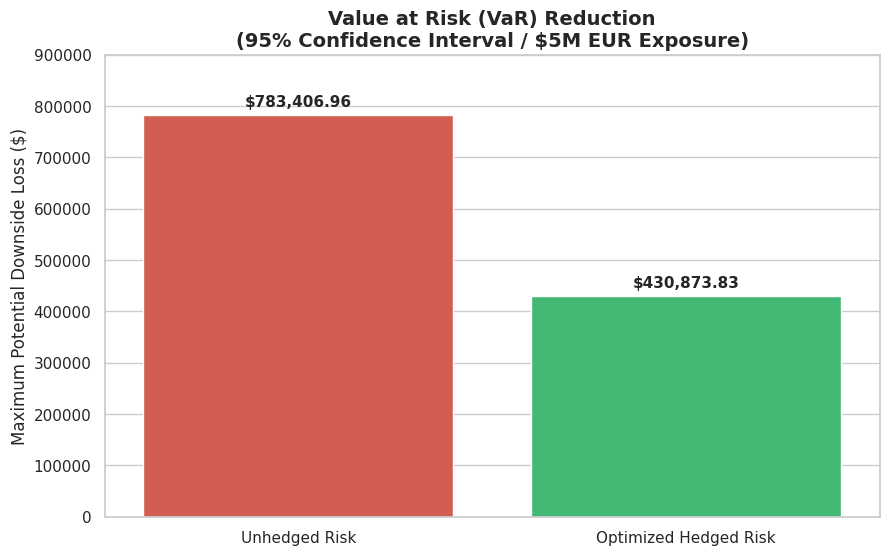

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Core Parameters & Unhedged Risk
net_exposure_eur = 5000000
z_score = 1.645
daily_volatility = 0.006
annualized_volatility = daily_volatility * np.sqrt(252)
unhedged_var = net_exposure_eur * z_score * annualized_volatility

# 2. Layered Hedging Policy (70% / 50% / 30%) & Optimized Risk
monthly_exposure = net_exposure_eur / 12
unhedged_m1_3 = 1.0 - 0.70
unhedged_m4_6 = 1.0 - 0.50
unhedged_m7_12 = 1.0 - 0.30

remaining_exposure = (monthly_exposure * 3 * unhedged_m1_3) + \
                     (monthly_exposure * 3 * unhedged_m4_6) + \
                     (monthly_exposure * 6 * unhedged_m7_12)

hedged_var = remaining_exposure * z_score * annualized_volatility

# 3. Executive Data Visualization
scenarios = ['Unhedged Risk', 'Optimized Hedged Risk']
risk_values = [unhedged_var, hedged_var]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the bar chart (FutureWarning avoided)
ax = sns.barplot(x=scenarios, y=risk_values, hue=scenarios, palette=['#e74c3c', '#2ecc71'], legend=False)

# Add formatting and titles
plt.title('Value at Risk (VaR) Reduction\n(95% Confidence Interval / $5M EUR Exposure)', fontsize=14, fontweight='bold')
plt.ylabel('Maximum Potential Downside Loss ($)', fontsize=12)
plt.ylim(0, 900000)

# Add the exact dollar amounts on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.show()

In [ ]:
import pandas as pd

# --- PART 1: SUPPLY CHAIN FINANCE (DPO EXTENSION) ---
# Simulating a hypothetical annual supplier spend to fit the $250M revenue baseline
annual_supplier_spend = 150000000  # $150M Annual Spend
current_dpo = 45
target_dpo = 90

daily_spend = annual_supplier_spend / 365
liquidity_unlocked = daily_spend * (target_dpo - current_dpo)

print(f"--- PHASE 2: SUPPLY CHAIN FINANCE (LIQUIDITY UNLOCKED) ---")
print(f"By extending DPO from {current_dpo} to {target_dpo} days, the architecture mathematically unlocks:")
print(f"${liquidity_unlocked:,.2f} in free working capital.\n")


# --- PART 2: MACROECONOMIC COST OF CARRY (INTEREST RATE PARITY) ---
# Evaluating forward premiums for a high-yield EM (MXN) vs Base (USD)
# Formula: Forward = Spot * (1 + (Quote_Rate * Days/360)) / (1 + (Base_Rate * Days/360))

spot_usd_mxn = 18.0000
usd_sofr_rate = 0.0525  # Hypothetical 5.25% USD Benchmark
mxn_tiie_rate = 0.1125  # Hypothetical 11.25% MXN Benchmark
forward_days = 90       # Hedging the 90-day unlocked liquidity

# Calculating the Interest Rate Parity
forward_usd_mxn = spot_usd_mxn * (1 + (mxn_tiie_rate * (forward_days / 360))) / (1 + (usd_sofr_rate * (forward_days / 360)))
forward_points = (forward_usd_mxn - spot_usd_mxn) * 10000

print(f"--- PHASE 2: MACROECONOMIC COST OF CARRY (USD/MXN) ---")
print(f"Spot Rate (USD/MXN):      {spot_usd_mxn:.4f}")
print(f"90-Day Forward Rate:      {forward_usd_mxn:.4f}")
print(f"Forward Points (Cost):    +{forward_points:.2f} points")
print(f"\nStrategic Insight: Because the MXN interest rate ({mxn_tiie_rate*100}%) is drastically higher than the USD rate ({usd_sofr_rate*100}%), the forward contract trades at a massive premium. This represents the explicit 'Cost of Carry' eroding operating margins.")

--- PHASE 2: SUPPLY CHAIN FINANCE (LIQUIDITY UNLOCKED) ---
By extending DPO from 45 to 90 days, the architecture mathematically unlocks:
$18,493,150.68 in free working capital.

--- PHASE 2: MACROECONOMIC COST OF CARRY (USD/MXN) ---
Spot Rate (USD/MXN):      18.0000
90-Day Forward Rate:      18.2665
Forward Points (Cost):    +2665.02 points

Strategic Insight: Because the MXN interest rate (11.25%) is drastically higher than the USD rate (5.25%), the forward contract trades at a massive premium. This represents the explicit 'Cost of Carry' eroding operating margins.


In [ ]:
# --- PART 3: ASYMMETRIC FX OPTIONS PAYOFF (UNCOMMITTED PIPELINE) ---
# Scenario: $5M EUR in uncommitted European sales pipeline.
# Strategy: Purchasing a EUR Put Option (Right to sell EUR at a guaranteed strike rate).

pipeline_eur = 5000000
strike_rate = 1.10     # Guaranteed minimum USD/EUR conversion rate
premium_per_eur = 0.02 # Upfront premium cost of the option per EUR
total_premium = pipeline_eur * premium_per_eur

# Simulating two future market scenarios when the deal finally closes:
spot_crash = 1.05  # Scenario A: EUR drops in value
spot_rally = 1.15  # Scenario B: EUR spikes in value

# Scenario A Math (Market crashes, so we execute the Option at the 1.10 Strike Rate)
unhedged_crash = pipeline_eur * spot_crash
hedged_crash = (pipeline_eur * strike_rate) - total_premium

# Scenario B Math (Market rallies, so we let Option expire and sell at the higher 1.15 Spot Rate)
unhedged_rally = pipeline_eur * spot_rally
hedged_rally = (pipeline_eur * spot_rally) - total_premium

print(f"--- PHASE 2: ASYMMETRIC FX OPTIONS (UNCOMMITTED EUR PIPELINE) ---")
print(f"Option Premium Paid: ${total_premium:,.2f} upfront cost to insure €{pipeline_eur:,.0f} of uncommitted revenue.\n")

print(f"SCENARIO A: EUR Crashes to {spot_crash} (Deal Closes)")
print(f"Unhedged Value:  ${unhedged_crash:,.2f}")
print(f"Option Value:    ${hedged_crash:,.2f}")
print(f"Executive Insight: The option protected the pipeline, saving the company ${hedged_crash - unhedged_crash:,.2f} net of the premium cost.\n")

print(f"SCENARIO B: EUR Rallies to {spot_rally} (Deal Closes)")
print(f"Unhedged Value:  ${unhedged_rally:,.2f}")
print(f"Option Value:    ${hedged_rally:,.2f}")
print(f"Executive Insight: Because this is an 'Asymmetric' hedge, we retain the upside. We let the option expire and convert at the higher market rate, absorbing the ${total_premium:,.2f} premium as an insurance cost.")

--- PHASE 2: ASYMMETRIC FX OPTIONS (UNCOMMITTED EUR PIPELINE) ---
Option Premium Paid: $100,000.00 upfront cost to insure €5,000,000 of uncommitted revenue.

SCENARIO A: EUR Crashes to 1.05 (Deal Closes)
Unhedged Value:  $5,250,000.00
Option Value:    $5,400,000.00
Executive Insight: The option protected the pipeline, saving the company $150,000.00 net of the premium cost.

SCENARIO B: EUR Rallies to 1.15 (Deal Closes)
Unhedged Value:  $5,750,000.00
Option Value:    $5,650,000.00
Executive Insight: Because this is an 'Asymmetric' hedge, we retain the upside. We let the option expire and convert at the higher market rate, absorbing the $100,000.00 premium as an insurance cost.


In [1]:
# --- PART 4: IN-HOUSE BANK (IHB) & VAM EFFICIENCY (POBO/COBO) ---
# Scenario: Scaling from a legacy decentralized structure to a centralized IHB using VAM.
# The company currently has 50 physical accounts across its global subsidiaries.

# 1. Bank Fee Reduction Modeling
physical_acct_fee_mo = 500   # Monthly maintenance fee per physical account
virtual_acct_fee_mo = 10     # Monthly maintenance fee per virtual account
num_subsidiary_accts = 50

# Legacy Cost (50 Physical Accounts)
legacy_annual_fees = (physical_acct_fee_mo * num_subsidiary_accts) * 12

# VAM Cost (1 Master Physical Header Account + 50 Virtual Accounts)
master_header_fee_mo = 1000
vam_annual_fees = (master_header_fee_mo * 12) + ((virtual_acct_fee_mo * num_subsidiary_accts) * 12)

fee_savings = legacy_annual_fees - vam_annual_fees

# 2. Trapped Cash (Liquidity Centralization) Modeling
# Physical accounts require local cash buffers to prevent overdrafts.
local_buffer_req = 50000
legacy_trapped_cash = local_buffer_req * num_subsidiary_accts

# VAM centralizes everything into 1 pool, requiring only 1 global buffer
ihb_central_buffer = 500000
unlocked_ihb_liquidity = legacy_trapped_cash - ihb_central_buffer

# Investing the newly unlocked centralized liquidity at the 5.25% SOFR rate (used in Cost of Carry)
yield_rate = 0.0525
annual_interest_gained = unlocked_ihb_liquidity * yield_rate

# --- OUTPUT ---
print(f"--- PHASE 2: IN-HOUSE BANK (IHB) & VAM POBO/COBO EFFICIENCY ---")
print(f"Legacy Physical Account Fees: ${legacy_annual_fees:,.2f} per year")
print(f"VAM Architecture Fees:        ${vam_annual_fees:,.2f} per year")
print(f"Annual Bank Fee Savings:      ${fee_savings:,.2f}\n")

print(f"Legacy Trapped Cash Buffers:  ${legacy_trapped_cash:,.2f}")
print(f"IHB Centralized Buffer:       ${ihb_central_buffer:,.2f}")
print(f"Liquidity Unlocked to Pool:   ${unlocked_ihb_liquidity:,.2f}")
print(f"New Annual Interest Yield:    ${annual_interest_gained:,.2f} (Calculated at {yield_rate*100}%)\n")

print(f"Executive Insight: Upgrading to POBO/COBO via Virtual Account Management eliminates ${fee_savings:,.0f} in redundant bank fees. Furthermore, centralizing subsidiary cash releases ${unlocked_ihb_liquidity:,.0f} in formerly trapped local liquidity, generating ${annual_interest_gained:,.0f} in new interest income.")

--- PHASE 2: IN-HOUSE BANK (IHB) & VAM POBO/COBO EFFICIENCY ---
Legacy Physical Account Fees: $300,000.00 per year
VAM Architecture Fees:        $18,000.00 per year
Annual Bank Fee Savings:      $282,000.00

Legacy Trapped Cash Buffers:  $2,500,000.00
IHB Centralized Buffer:       $500,000.00
Liquidity Unlocked to Pool:   $2,000,000.00
New Annual Interest Yield:    $105,000.00 (Calculated at 5.25%)

Executive Insight: Upgrading to POBO/COBO via Virtual Account Management eliminates $282,000 in redundant bank fees. Furthermore, centralizing subsidiary cash releases $2,000,000 in formerly trapped local liquidity, generating $105,000 in new interest income.
